# 01 — Exploratory Data Analysis (EDA)
## Predicting Hospital Readmission in Diabetic Patients

**Dataset :** Diabetes 130-US Hospitals (1999-2008)  
**Target :** Predict whether a diabetic patient will be readmitted within 30 days of discharge  
**Problem type :** Supervised Binary Classification

---
### Notebook Objectives
1. Understand the dataset structure and metadata
2. Analyze the target variable distribution
3. Detect missing values and outliers
4. Explore numeric and categorical feature distributions
5. Analyze correlations with the target
6. Define preprocessing decisions for Notebook 02

## 1. Imports & Setup

In [1]:
# importing the libraries we'll need throughout this notebook
# pandas     -> working with tabular data (DataFrames)
# numpy      -> numerical operations
# matplotlib -> basic plotting
# seaborn    -> statistical charts
# scipy      -> statistical tests (t-test, chi-square)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# global chart style — keeps all plots consistent and clean
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        10
})

# color palette used across all charts in this notebook
BLUE   = '#2E86AB'   # majority class / neutral
RED    = '#E84855'   # minority class / alert
GREEN  = '#2ECC71'   # low risk
ORANGE = '#F39C12'   # moderate risk

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Load Data

In [2]:
# loading the CSV file
# na_values='?' : missing values in this dataset are coded as '?'
# we convert them to NaN so pandas can handle them with standard tools
df = pd.read_csv('diabetic_data.csv', na_values='?')

print(f'Shape              : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Duplicate rows     : {df.duplicated().sum()}')
print(f'Total missing vals : {df.isna().sum().sum():,}')

# quick check of the first 5 rows to confirm the file loaded correctly
df.head()

Shape              : 101,766 rows x 50 columns
Duplicate rows     : 0
Total missing vals : 374,017


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 3. Dataset Overview

In [3]:
# summary table for each column:
#   dtype    -> variable type (int64, object, float64...)
#   missing  -> absolute count of missing values
#   miss_%   -> percentage of missing values
#   nunique  -> number of distinct values
# this is the fastest way to spot problematic columns at a glance
overview = pd.DataFrame({
    'dtype':   df.dtypes,
    'missing': df.isna().sum(),
    'miss_%':  (df.isna().mean() * 100).round(2),
    'nunique': df.nunique(),
})
print(overview.to_string())

                           dtype  missing  miss_%  nunique
encounter_id               int64        0    0.00   101766
patient_nbr                int64        0    0.00    71518
race                      object     2273    2.23        5
gender                    object        0    0.00        3
age                       object        0    0.00       10
weight                    object    98569   96.86        9
admission_type_id          int64        0    0.00        8
discharge_disposition_id   int64        0    0.00       26
admission_source_id        int64        0    0.00       17
time_in_hospital           int64        0    0.00       14
payer_code                object    40256   39.56       17
medical_specialty         object    49949   49.08       72
num_lab_procedures         int64        0    0.00      118
num_procedures             int64        0    0.00        7
num_medications            int64        0    0.00       75
number_outpatient          int64        0    0.00       

In [4]:
# descriptive statistics for the numeric features
# shows: count, mean, std, min, 25%, 50%, 75%, max
# useful for spotting skewed distributions and potential extreme values
num_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications',  'number_diagnoses',
    'number_outpatient','number_emergency',   'number_inpatient'
]
df[num_cols].describe().round(2)

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,number_outpatient,number_emergency,number_inpatient
count,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,4.40,43.10,1.34,16.02,7.42,0.37,0.20,0.64
std,2.99,19.67,1.71,8.13,1.93,1.27,0.93,1.26
min,1.00,1.00,0.00,1.00,1.00,0.00,0.00,0.00
25%,2.00,31.00,0.00,10.00,6.00,0.00,0.00,0.00
50%,4.00,44.00,1.00,15.00,8.00,0.00,0.00,0.00
75%,6.00,57.00,2.00,20.00,9.00,0.00,0.00,1.00
max,14.00,132.00,6.00,81.00,16.00,42.00,76.00,21.00


## 4. Target Variable Analysis

Original distribution (3 classes):
readmitted
NO     54864
>30    35545
<30    11357

Binary target (0 / 1):
readmitted_30
0    90409
1    11357

Positive class rate (<30d): 11.2%
Class imbalance detected — SMOTE will be applied during preprocessing


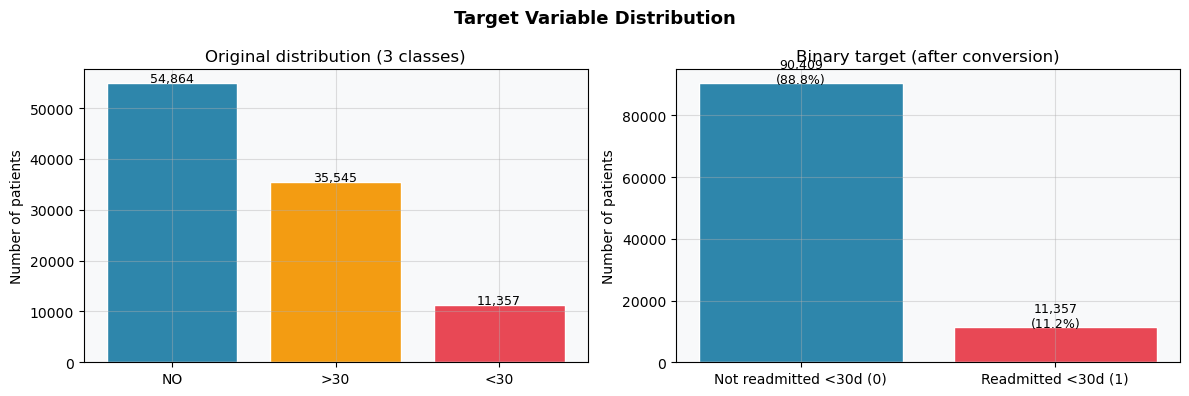

In [5]:
# the original 'readmitted' column has 3 classes:
#   '<30' -> readmitted within 30 days  (our positive class)
#   '>30' -> readmitted after 30 days
#   'NO'  -> never readmitted
#
# we convert it to a BINARY target:
#   1 -> readmitted within 30 days  (clinically urgent case)
#   0 -> all other cases
#
# the business goal is to catch early readmissions (<30d) so we can
# intervene in time. readmission after 30 days or none at all are
# both treated as acceptable outcomes.
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

print('Original distribution (3 classes):')
print(df['readmitted'].value_counts().to_string())
print(f'\nBinary target (0 / 1):')
print(df['readmitted_30'].value_counts().to_string())
print(f'\nPositive class rate (<30d): {df["readmitted_30"].mean()*100:.1f}%')
print('Class imbalance detected — SMOTE will be applied during preprocessing')

# plot both distributions side by side for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold')

# chart 1: original 3-class distribution
vc = df['readmitted'].value_counts()
bars = axes[0].bar(vc.index, vc.values, color=[BLUE, ORANGE, RED], edgecolor='white')
axes[0].set_title('Original distribution (3 classes)')
axes[0].set_ylabel('Number of patients')
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+200,
                 f'{b.get_height():,}', ha='center', fontsize=9)

# chart 2: binary target after conversion
vc2 = df['readmitted_30'].value_counts().sort_index()
bars2 = axes[1].bar(['Not readmitted <30d (0)', 'Readmitted <30d (1)'],
                     vc2.values, color=[BLUE, RED], edgecolor='white')
axes[1].set_title('Binary target (after conversion)')
axes[1].set_ylabel('Number of patients')
for b in bars2:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+200,
                 f'{b.get_height():,}\n({b.get_height()/len(df)*100:.1f}%)',
                 ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Missing Values Analysis

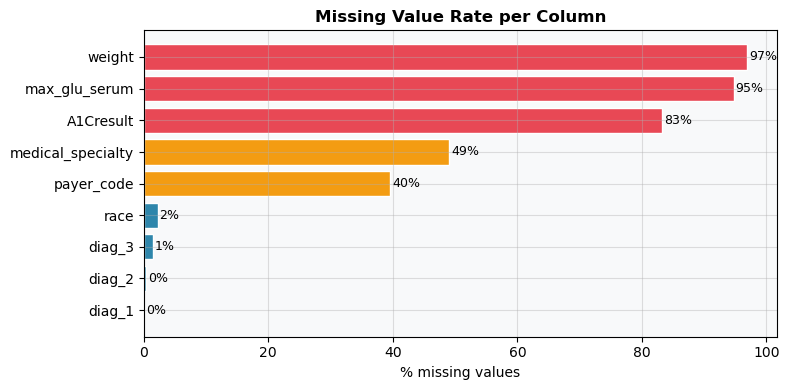

Treatment decisions:
  weight            (97%) -> DROP — almost no data available
  medical_specialty (53%) -> DROP — too sparse + purely administrative
  payer_code        (52%) -> DROP — too sparse + purely administrative
  race               (2%) -> IMPUTE with "Unknown" (clinically valid category)


In [6]:
# calculate the missing rate for each column and visualize it
# the rule we follow for deciding what to do:
#   > 50% missing  -> drop the column entirely (not enough useful data)
#   20-50% missing -> drop if not clinically critical
#   2-20%  missing -> impute (median for numeric, mode for categorical)
miss = df.isna().mean() * 100
miss = miss[miss > 0].sort_values(ascending=False)

# color the bars by severity so the decision is obvious at a glance
colors = [RED if v > 50 else ORANGE if v > 20 else BLUE for v in miss.values]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(miss.index, miss.values, color=colors, edgecolor='white')
ax.set_xlabel('% missing values')
ax.set_title('Missing Value Rate per Column', fontweight='bold')
ax.invert_yaxis()
# annotate each bar with the exact percentage
for bar, val in zip(bars, miss.values):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Treatment decisions:')
print('  weight            (97%) -> DROP — almost no data available')
print('  medical_specialty (53%) -> DROP — too sparse + purely administrative')
print('  payer_code        (52%) -> DROP — too sparse + purely administrative')
print('  race               (2%) -> IMPUTE with "Unknown" (clinically valid category)')

## 6. Outlier Detection (IQR Method)

           Feature  N outliers  % outliers  Lower bound  Upper bound
 number_outpatient       16739       16.45          0.0          0.0
  number_emergency       11383       11.19          0.0          0.0
  number_inpatient        7049        6.93         -1.5          2.5
    num_procedures        4954        4.87         -3.0          5.0
   num_medications        2557        2.51         -5.0         35.0
  time_in_hospital        2252        2.21         -4.0         12.0
  number_diagnoses         281        0.28          1.5         13.5
num_lab_procedures         143        0.14         -8.0         96.0


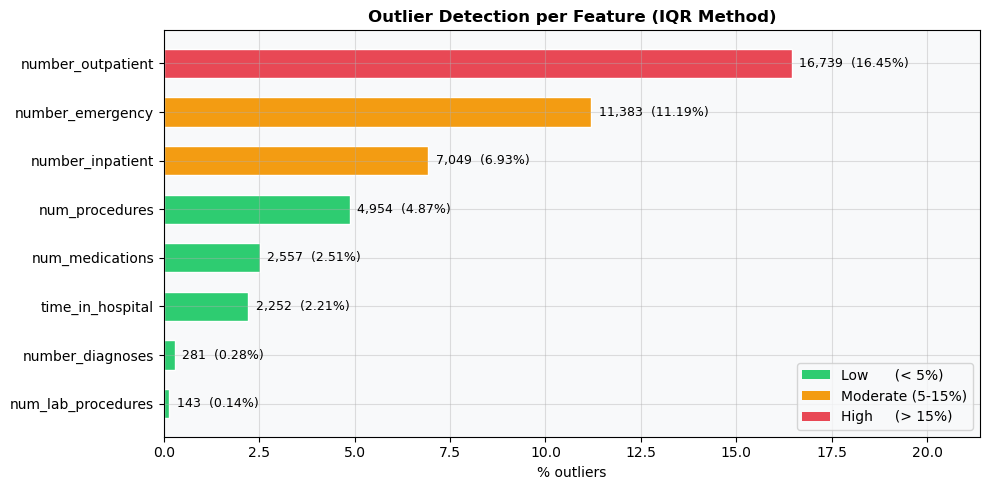

In [7]:
# IQR (Inter-Quartile Range) method:
#   Q1  = 25th percentile
#   Q3  = 75th percentile
#   IQR = Q3 - Q1
#
#   lower bound = Q1 - 1.5 * IQR
#   upper bound = Q3 + 1.5 * IQR
#
# any value outside this range is flagged as an outlier —
# same rule used by box plots
def count_outliers_iqr(series):
    Q1     = series.quantile(0.25)
    Q3     = series.quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR   # lower bound
    upper  = Q3 + 1.5 * IQR   # upper bound
    n_out  = ((series < lower) | (series > upper)).sum()
    return n_out, lower, upper

# run the check on every numeric feature
outlier_report = []
for col in num_cols:
    n_out, lo, hi = count_outliers_iqr(df[col].dropna())
    outlier_report.append({
        'Feature':     col,
        'N outliers':  n_out,
        '% outliers':  round(n_out / len(df) * 100, 2),
        'Lower bound': round(lo, 2),
        'Upper bound': round(hi, 2)
    })

outlier_df = pd.DataFrame(outlier_report).sort_values('N outliers', ascending=False)
print(outlier_df.to_string(index=False))

# horizontal bar chart — color coded by severity level
fig, ax = plt.subplots(figsize=(10, 5))
colors  = [RED if p > 15 else ORANGE if p > 5 else GREEN
           for p in outlier_df['% outliers']]
bars    = ax.barh(outlier_df['Feature'], outlier_df['% outliers'],
                  color=colors, edgecolor='white', height=0.6)
ax.set_xlabel('% outliers')
ax.set_title('Outlier Detection per Feature (IQR Method)', fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, outlier_df['% outliers'].max() * 1.3)
# show count and percentage on each bar
for bar, pct, n in zip(bars, outlier_df['% outliers'], outlier_df['N outliers']):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'{n:,}  ({pct}%)', va='center', fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=GREEN,  label='Low      (< 5%)'),
    Patch(facecolor=ORANGE, label='Moderate (5-15%)'),
    Patch(facecolor=RED,    label='High     (> 15%)'),
], loc='lower right')
plt.tight_layout()
plt.show()

## 7. Numeric Feature Distributions

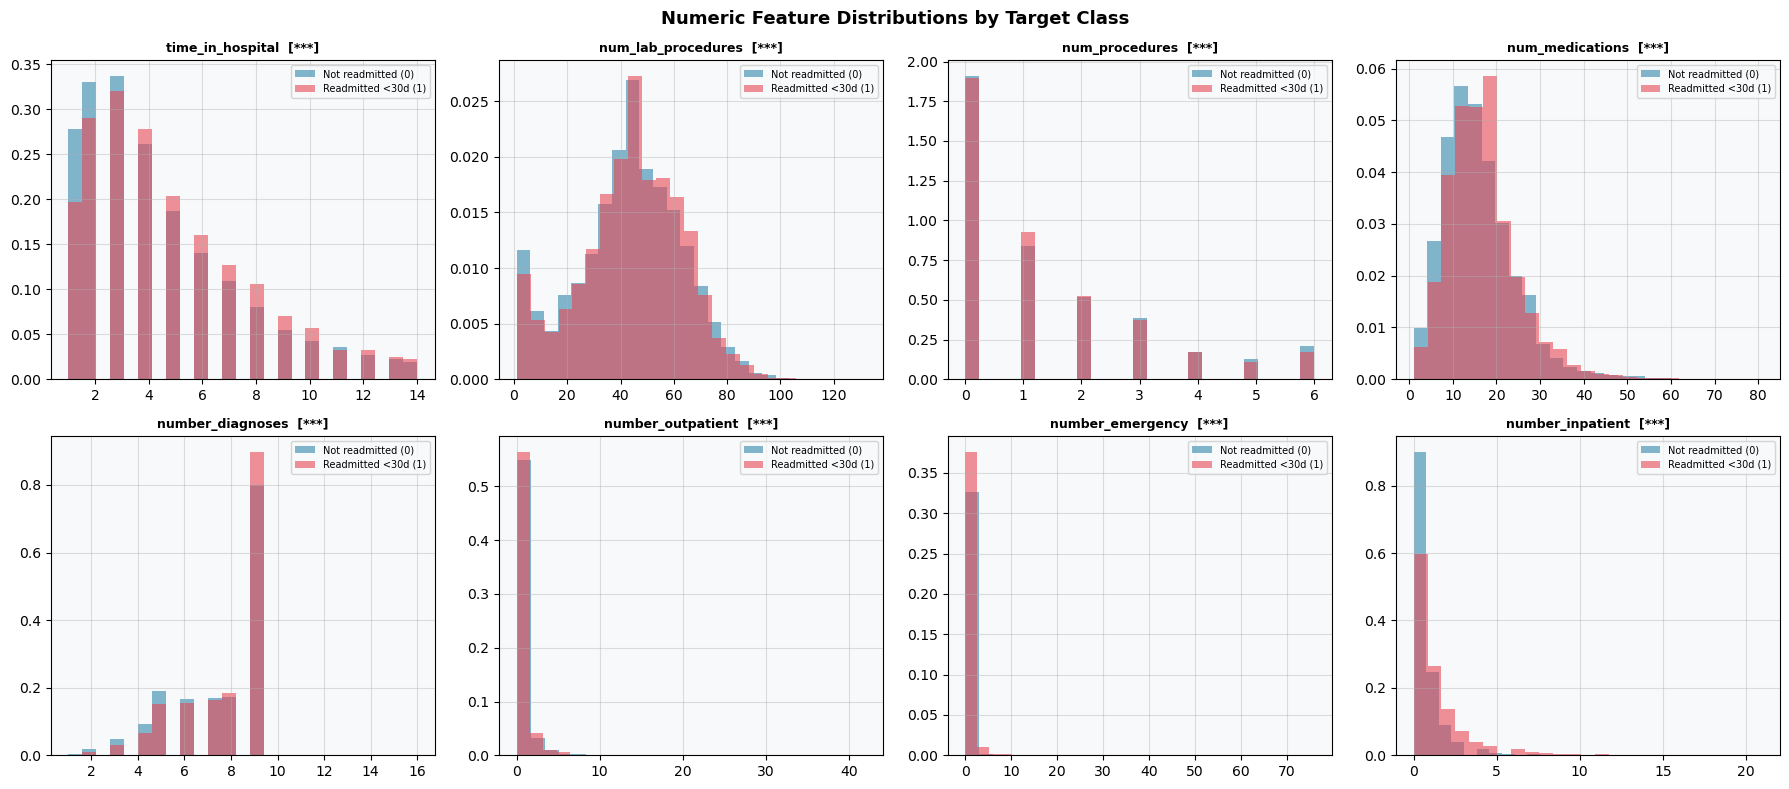

Legend: *** p<0.001 | ** p<0.01 | * p<0.05 | ns = not significant


In [8]:
# for each numeric feature, compare the distribution
# across the two target classes (0 = not readmitted, 1 = readmitted)
#
# statistical test: Welch's t-test
#   does not assume equal variances between the two groups
#   H0: no difference in means between the two classes
#   if p < 0.05 -> we reject H0 -> this feature is discriminative
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Numeric Feature Distributions by Target Class',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes.flat, num_cols):
    # split data by target class
    d0 = df.loc[df['readmitted_30'] == 0, col].dropna()
    d1 = df.loc[df['readmitted_30'] == 1, col].dropna()

    # overlapping histograms — density=True makes them comparable
    ax.hist(d0, bins=25, alpha=0.6, color=BLUE, label='Not readmitted (0)', density=True)
    ax.hist(d1, bins=25, alpha=0.6, color=RED,  label='Readmitted <30d (1)', density=True)

    # run Welch t-test and add significance markers to the title
    _, p = stats.ttest_ind(d0, d1, equal_var=False)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

    ax.set_title(f'{col}  [{sig}]', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()
print('Legend: *** p<0.001 | ** p<0.01 | * p<0.05 | ns = not significant')

## 8. Categorical Feature Analysis

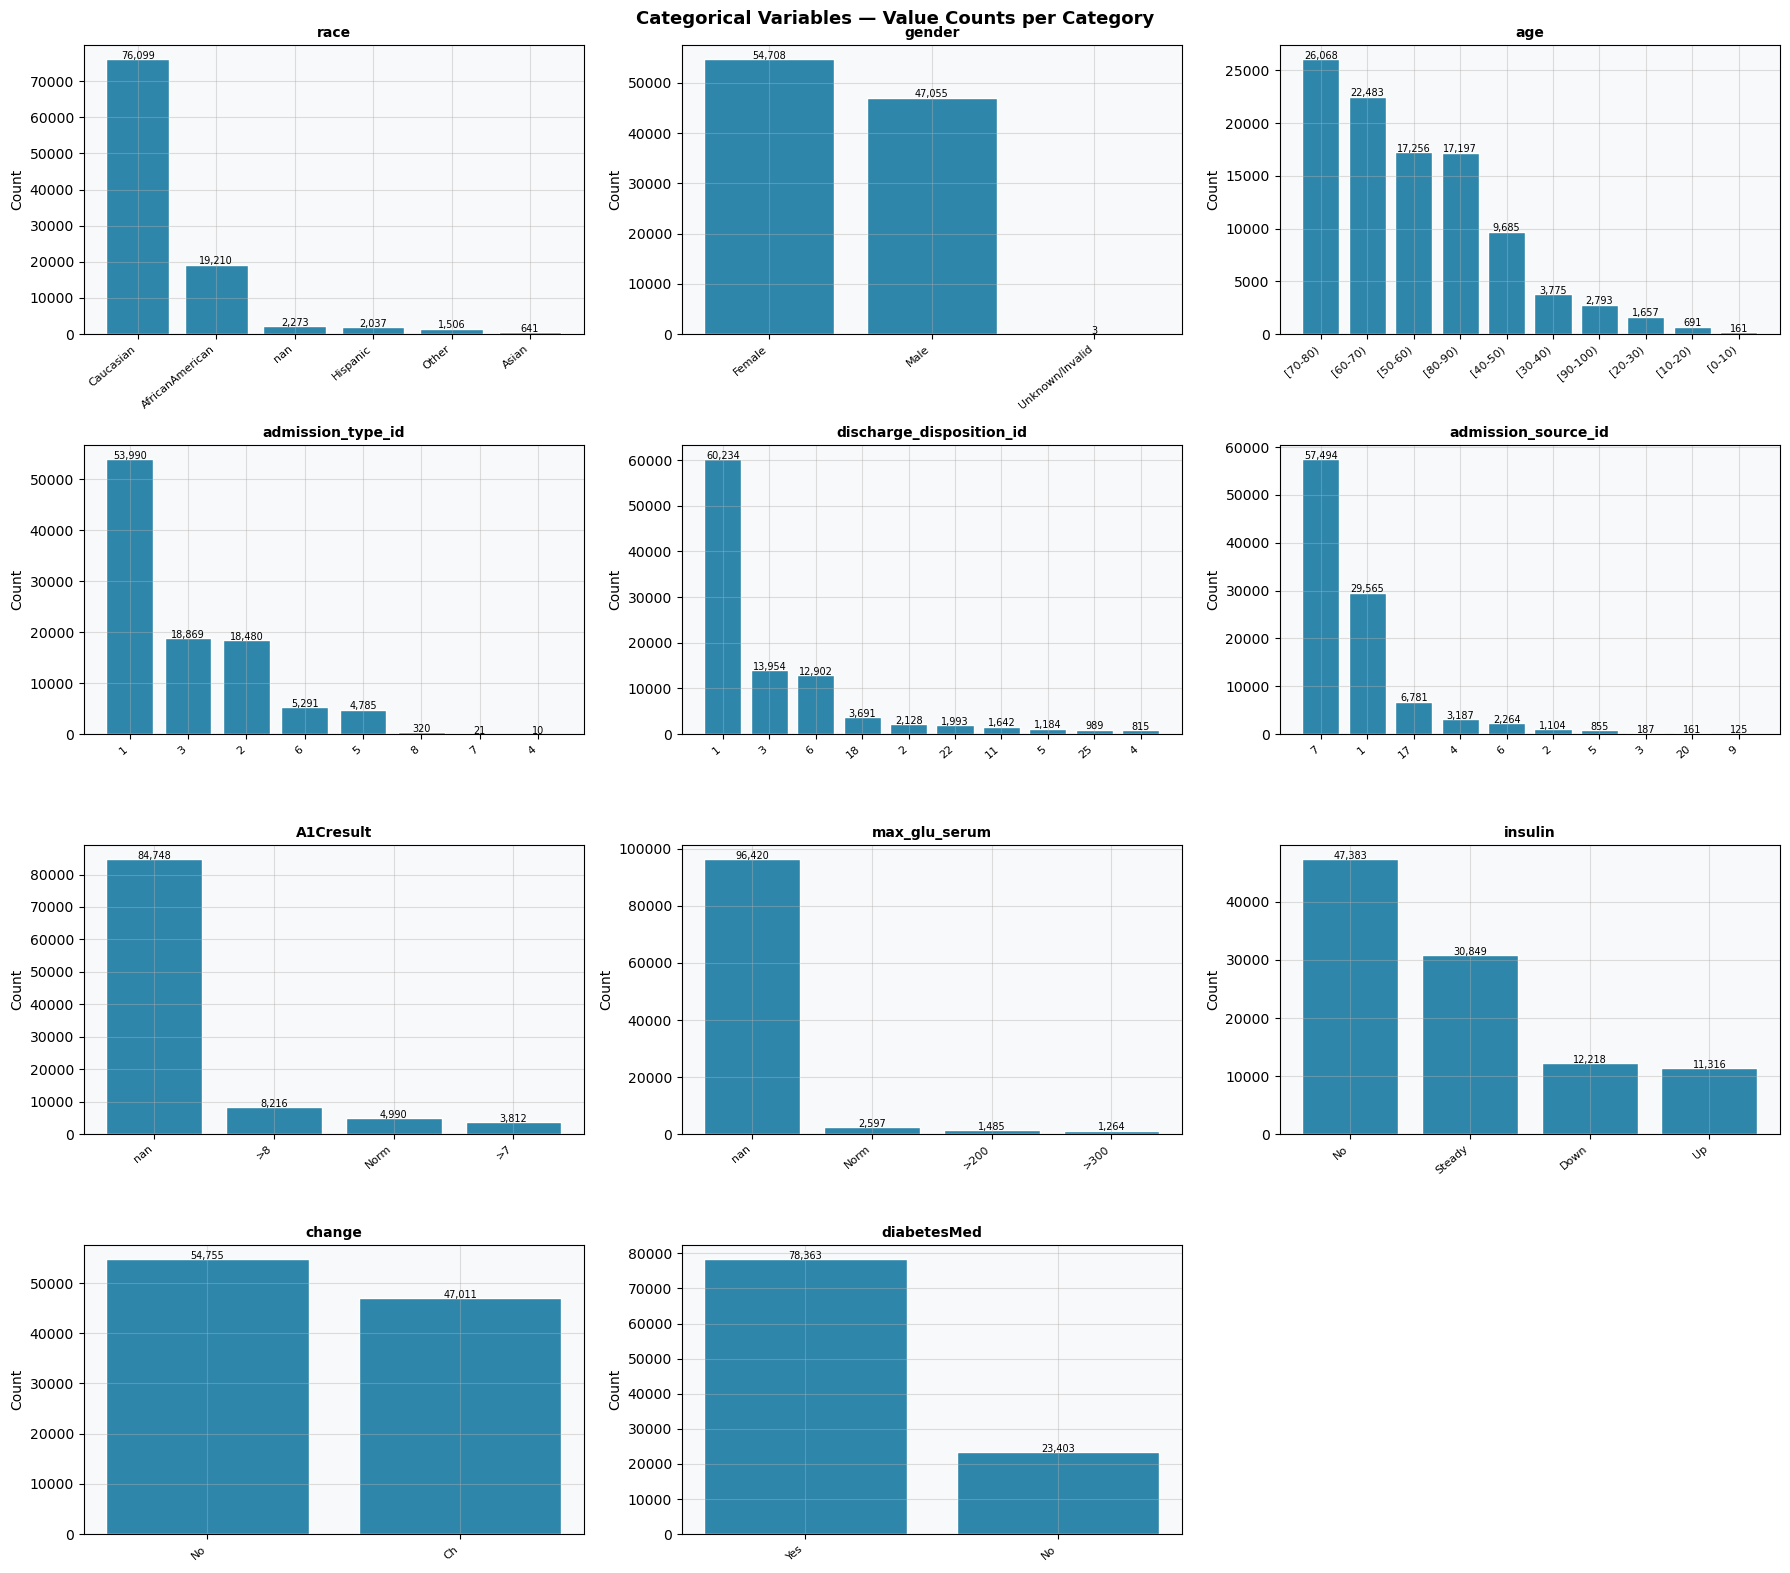

In [9]:
# categorical features selected for this analysis:
#   - demographic    : race, gender, age
#   - administrative : admission_type, discharge, source
#   - clinical       : A1Cresult, max_glu_serum, insulin
#   - medication     : change, diabetesMed
#
# we skip diag_1/2/3 here — they have 800+ unique values
# and will be grouped into ICD-9 categories during preprocessing
cat_features = [
    'race', 'gender', 'age', 'admission_type_id',
    'discharge_disposition_id', 'admission_source_id',
    'A1Cresult', 'max_glu_serum', 'insulin', 'change', 'diabetesMed'
]
cat_features = [c for c in cat_features if c in df.columns]

n     = len(cat_features)
ncols = 3
nrows = (n + ncols - 1) // ncols

# chart 1: value counts — how many patients per category
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
fig.suptitle('Categorical Variables — Value Counts per Category',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes.flat, cat_features):
    # show top 10 most frequent values only
    vc = df[col].astype(str).value_counts().head(10)
    ax.bar(range(len(vc)), vc.values, color=BLUE, edgecolor='white')
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=40, ha='right', fontsize=8)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Count')
    # annotate each bar with its count
    for bar in ax.patches:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                f'{int(bar.get_height()):,}', ha='center', fontsize=7)

# hide any unused subplots at the end
for ax in list(axes.flat)[len(cat_features):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

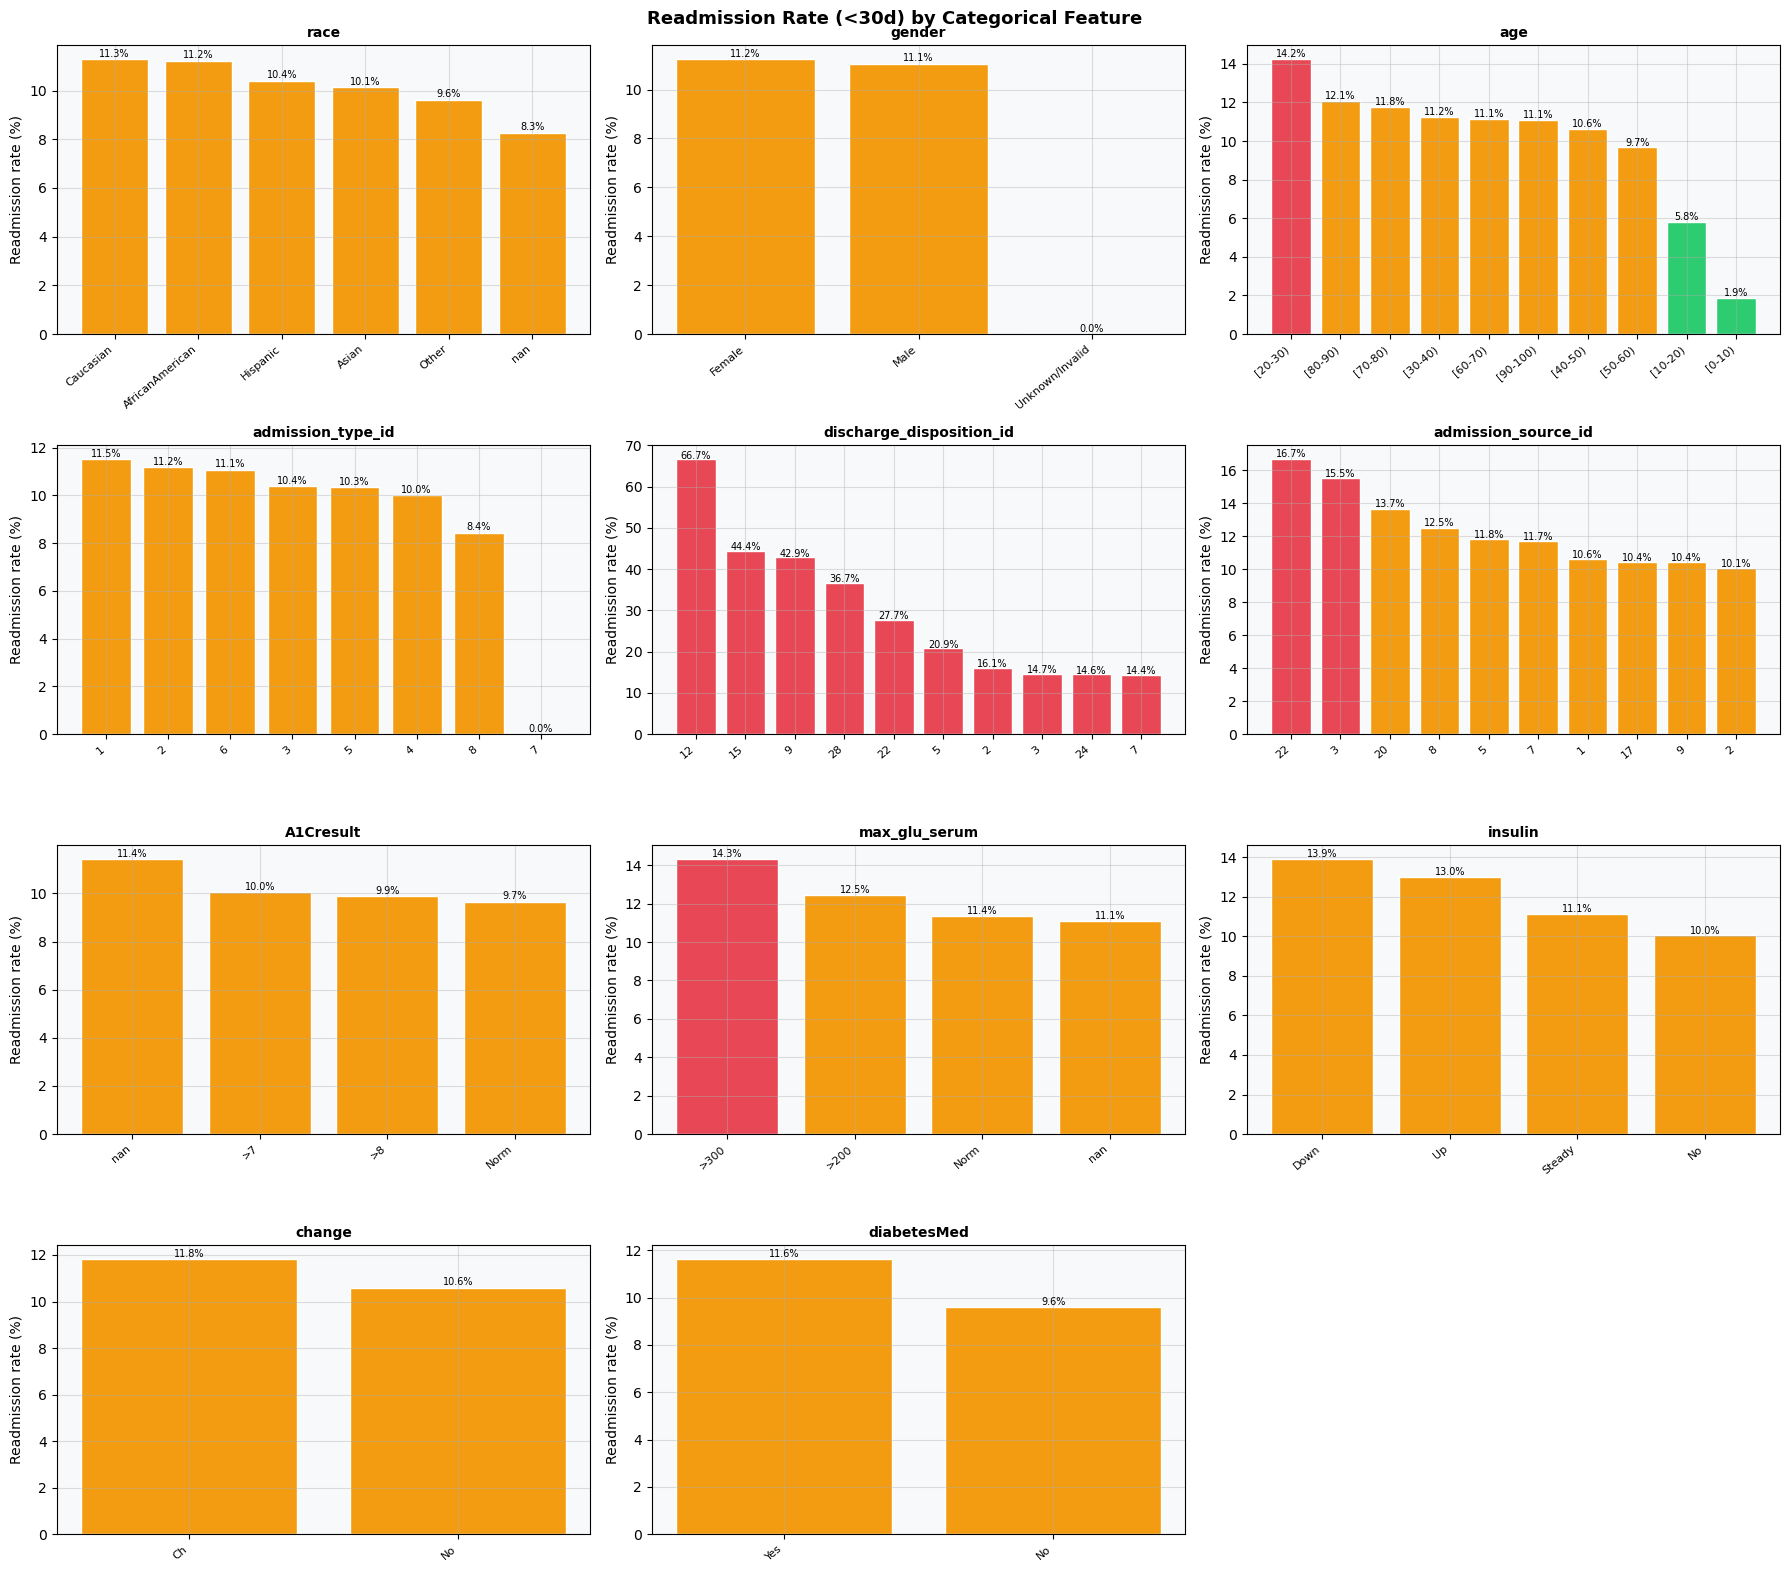

In [10]:
# chart 2: readmission rate per category value
# for each category, we compute the proportion of patients
# readmitted within 30 days
#
# color coding by risk level:
#   green  -> rate < 8%   (low risk)
#   orange -> rate 8-14%  (moderate risk)
#   red    -> rate > 14%  (high risk)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
fig.suptitle('Readmission Rate (<30d) by Categorical Feature',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes.flat, cat_features):
    # mean readmission rate per category, sorted descending
    rate = (df.groupby(df[col].astype(str))['readmitted_30']
              .mean()
              .sort_values(ascending=False)
              .head(10))

    # pick bar color based on risk level
    bar_colors = [
        RED if v > 0.14 else ORANGE if v > 0.08 else GREEN
        for v in rate.values
    ]

    ax.bar(range(len(rate)), rate.values * 100,
           color=bar_colors, edgecolor='white')
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate.index, rotation=40, ha='right', fontsize=8)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Readmission rate (%)')

    # annotate each bar with the exact rate
    for bar in ax.patches:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f'{bar.get_height():.1f}%', ha='center', fontsize=7)

for ax in list(axes.flat)[len(cat_features):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## 9. Correlation with Target Variable

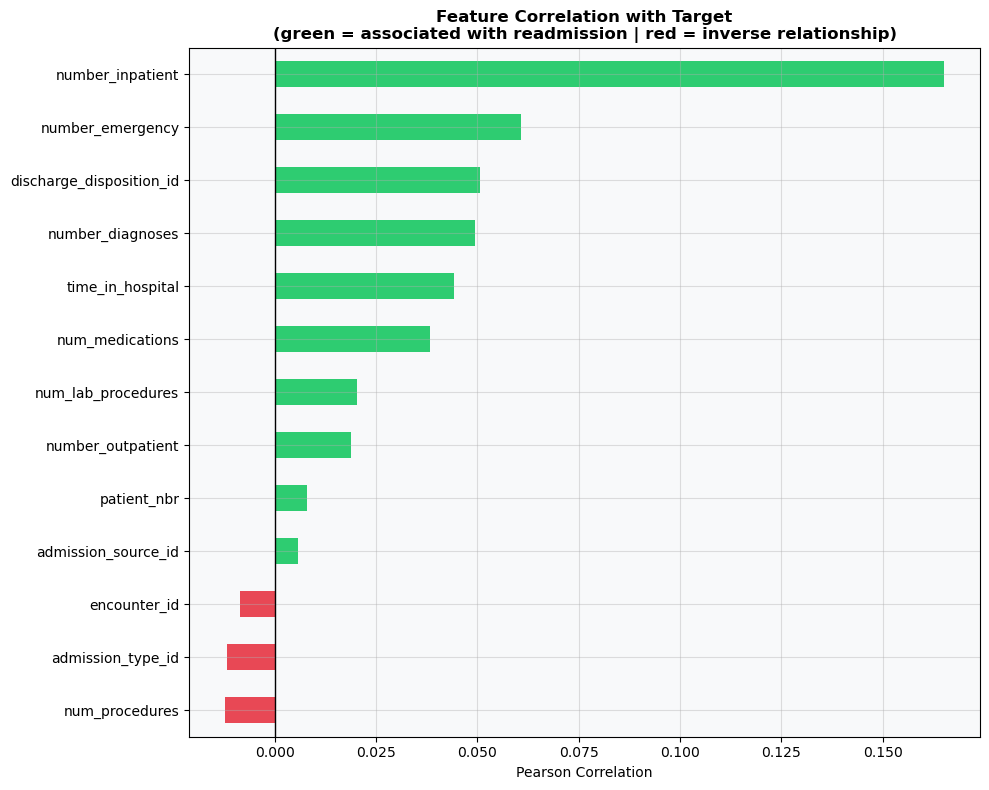

Top 5 features positively correlated with readmission (<30d):
time_in_hospital            0.0442
number_diagnoses            0.0495
discharge_disposition_id    0.0506
number_emergency            0.0607
number_inpatient            0.1651

Top 5 features negatively correlated with readmission:
num_procedures        -0.0122
admission_type_id     -0.0117
encounter_id          -0.0085
admission_source_id    0.0058
patient_nbr            0.0079


In [11]:
# Pearson correlation between each numeric feature and the binary target
#
# how to read this chart:
#   green bar (positive) -> when this feature goes up,
#     readmission probability tends to go up too
#   red bar (negative)   -> when this feature goes up,
#     readmission probability tends to go down
#
# keep in mind: Pearson only captures linear relationships
# tree-based models (RF, GB) will pick up non-linear patterns on top of this
df_corr = df.copy()

# only compute on numeric columns
corr_with_target = (
    df_corr
    .select_dtypes(include=[np.number])
    .corr()['readmitted_30']
    .drop('readmitted_30')   # drop self-correlation
    .sort_values()
)

# green = positively correlated, red = negatively correlated
colors = [RED if x < 0 else GREEN for x in corr_with_target]

fig, ax = plt.subplots(figsize=(10, 8))
corr_with_target.plot(kind='barh', ax=ax, color=colors)
ax.axvline(x=0, color='black', linewidth=1)   # zero reference line
ax.set_title(
    'Feature Correlation with Target\n'
    '(green = associated with readmission | red = inverse relationship)',
    fontweight='bold', fontsize=12
)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print('Top 5 features positively correlated with readmission (<30d):')
print(corr_with_target.tail(5).round(4).to_string())
print('\nTop 5 features negatively correlated with readmission:')
print(corr_with_target.head(5).round(4).to_string())

## 10. EDA Summary — Preprocessing Decisions

In [12]:
# structured summary of all decisions taken based on the EDA findings
# everything listed here will be implemented step by step in Notebook 02
print('=' * 70)
print('EDA SUMMARY — PREPROCESSING DECISIONS')
print('=' * 70)

decisions = [
    ('Missing values',     'weight(97%), payer_code(52%), medical_specialty(53%) -> Drop'),
    ('Duplicates',         'Checked -> Remove if present'),
    ('Class imbalance',    'Severe (89% vs 11%) -> SMOTE on train set only'),
    ('Outliers',           'number_outpatient, number_emergency -> heavy right skew'),
    ('Categorical vars',   'Label encoding (binary), One-Hot encoding (nominal)'),
    ('Normalization',      'StandardScaler for LR (required), not needed for trees'),
    ('Feature Engineering','5 new features: n_active_meds, n_med_changes, prior_visits, age_mid, ICD-9 groups'),
    ('Feature Selection',  'Based on Random Forest / Gradient Boosting importance'),
    ('Metrics',            'F1-score + ROC-AUC + Confusion Matrix'),
]

for i, (aspect, decision) in enumerate(decisions, 1):
    print(f'  {i:2d}. {aspect:<27s} -> {decision}')

print('\nMost discriminative features identified:')
print('   -> number_inpatient    (strongest predictor of readmission)')
print('   -> time_in_hospital    (longer stay = more complex case)')
print('   -> num_medications     (more drugs = more complex treatment)')
print('   -> insulin             (glycemic management — key diabetes signal)')
print('   -> number_diagnoses    (comorbidity burden)')

EDA SUMMARY — PREPROCESSING DECISIONS
   1. Missing values              -> weight(97%), payer_code(52%), medical_specialty(53%) -> Drop
   2. Duplicates                  -> Checked -> Remove if present
   3. Class imbalance             -> Severe (89% vs 11%) -> SMOTE on train set only
   4. Outliers                    -> number_outpatient, number_emergency -> heavy right skew
   5. Categorical vars            -> Label encoding (binary), One-Hot encoding (nominal)
   6. Normalization               -> StandardScaler for LR (required), not needed for trees
   7. Feature Engineering         -> 5 new features: n_active_meds, n_med_changes, prior_visits, age_mid, ICD-9 groups
   8. Feature Selection           -> Based on Random Forest / Gradient Boosting importance
   9. Metrics                     -> F1-score + ROC-AUC + Confusion Matrix

Most discriminative features identified:
   -> number_inpatient    (strongest predictor of readmission)
   -> time_in_hospital    (longer stay = more comp

In [13]:
df.to_csv('cleaned_data.csv', index=False)
print("✅ Cleaned data saved to 'cleaned_data.csv'")

✅ Cleaned data saved to 'cleaned_data.csv'
